# Additional Environmental Distribution Analysis

This notebook uses data found from the BacDive to view environmental distriubtion of entries:

## Key Features

- View found environmental classifications of bacterial classes 
- Removes duplicate entries that arise from different protein sequences from same species


In [13]:
!pip install ete3
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 968.6 kB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.1 MB 997.9 kB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.1 MB 997.9 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.1 MB 1.0 MB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.1 MB 1.0 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.1 MB 993.2 kB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.1 MB 993.2 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 995.9 kB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.1 MB 996.9 kB/s eta 0:00:07
   ----------- ---------------------------- 2.4/8.1 MB 1.0 MB/s eta 0:00:06
   ------------ ---

In [2]:
import pandas as pd
from collections import defaultdict

# Load environmental classification data
env_df = pd.read_csv(
    "results/environment/vgsc_min100_max500_cdhit_0.90_bacdive_source_info_found_cleaned_environmental_distribution_final_environmental_classification.csv"
)

# Load taxonomy lineage data
tax_df = pd.read_csv(
    "results/sequences/vgsc_min100_max500_cdhit_0.90_taxonomy_lineages.csv"
)

# Merge using taxonomy_id (safer and more consistent than names)
merged_df = pd.merge(env_df, tax_df, on="taxonomy_id", how="inner")

# Build a DataFrame with class, species_name, and environment
output_rows = []

for _, row in merged_df.iterrows():
    class_name = row['class']  # taxonomic class
    species_name = row['organism_from_ncb_x']  # species name (adjust if column name differs)
    env = row['environmental_classification']
    
    output_rows.append({
        "class": class_name,
        "species_name": species_name,
        "environmental_classification": env
    })

# Convert to DataFrame
output_df = pd.DataFrame(output_rows)

# Save to CSV
output_df.to_csv("species_environment_by_class.csv", index=False)

print("CSV file 'species_environment_by_class.csv' created successfully!")
print(f"Merged entries: {len(merged_df)}")
print(f"Environmental entries: {len(env_df)}")
print(f"Taxonomy entries: {len(tax_df)}")


CSV file 'species_environment_by_class.csv' created successfully!
Merged entries: 431
Environmental entries: 392
Taxonomy entries: 828


In [15]:
print(merged_df)

                organism_from_ncb_x  taxonomy_id strain_id  \
0           Shewanella putrefaciens           24        97   
1        Ectopseudomonas oleovorans          301       RS1   
2                 Vibrio vulnificus          672  FORC_017   
3          Ruminobacter amylophilus          867  DSM 1361   
4          Ruminobacter amylophilus          867  DSM 1361   
..                              ...          ...       ...   
426        Salibaculum griseiflavum      1914409   WDS4C29   
427     Halalkalibacillus sediminis      2018042     B3227   
428            Neptunicoccus cionae      2035344       m18   
429                Arenimonas caeni      2058085       z29   
430  Jeotgalibacillus proteolyticus      2082395      22-7   

                                          bacdive_id  \
0                                              14054   
1    12869;131006;161427;161428;161431;161433;161435   
2                                      164792;164793   
3                              


=== Overall Environment Counts ===
environmental_classification
aquatic               233
multienvironmental    125
soil                   53
animal                 14
plant                   6
Name: count, dtype: int64

=== Counts per Class ===
environmental_classification  animal  aquatic  multienvironmental  plant  soil
class                                                                         
Actinomycetes                      3        1                  29      6    48
Alphaproteobacteria                2      151                  25      0     3
Bacilli                            3        2                  40      0     2
Bacteroidia                        0        2                   0      0     0
Betaproteobacteria                 0        1                   1      0     0
Cytophagia                         1        2                   0      0     0
Desulfobacteria                    0        1                   0      0     0
Desulfovibrionia                   0      

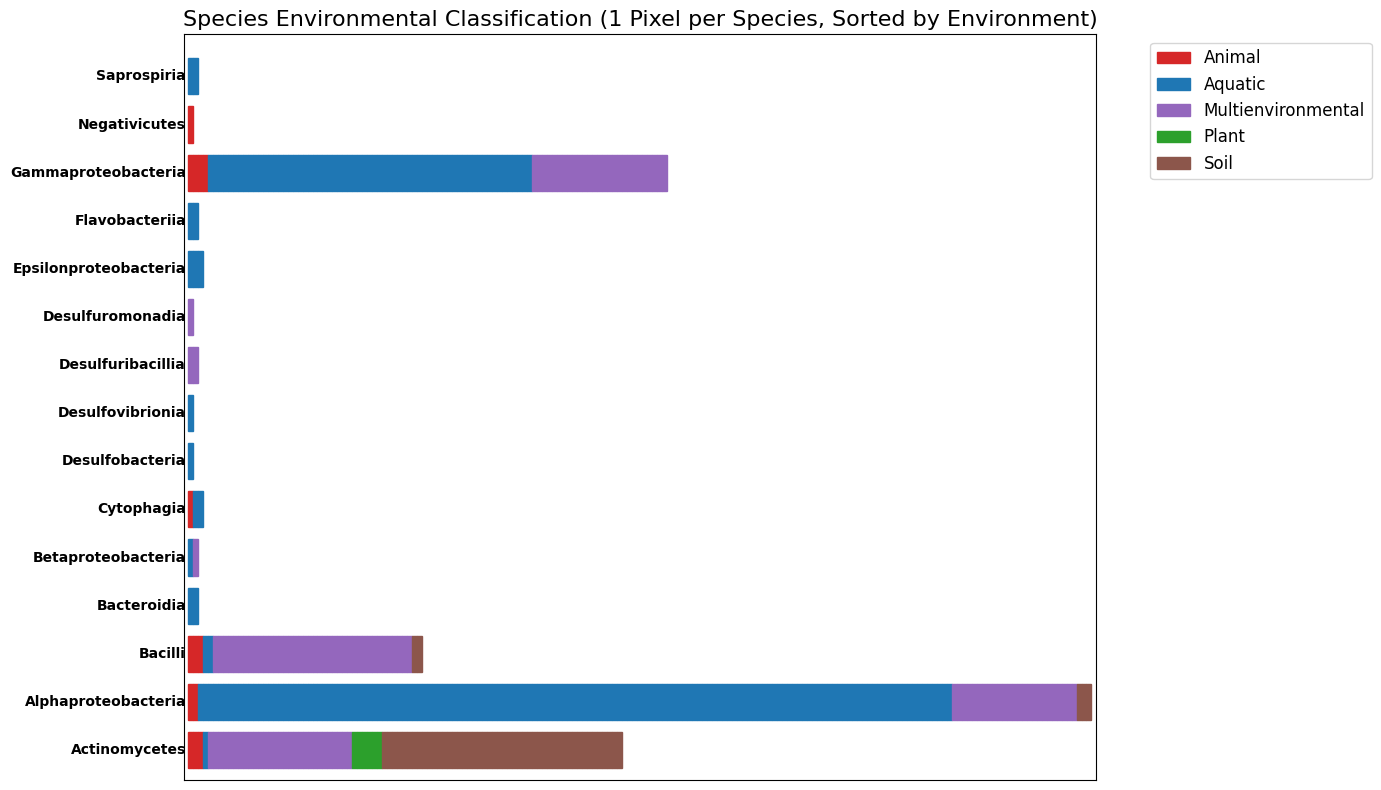

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load your real processed CSV file
merged_df = pd.read_csv("species_environment_by_class.csv")

# Normalize 'environmental_classification'
merged_df['environmental_classification'] = (
    merged_df['environmental_classification']
    .str.strip()
    .str.lower()
)

# Unify multi-environment keys
merged_df['environmental_classification'] = merged_df['environmental_classification'].replace({
    'multi-environment': 'multienvironmental',
    'multienvironmental': 'multienvironmental'
})

# =========================
# 🔢 PRINT VALUES
# =========================

print("\n=== Overall Environment Counts ===")
print(merged_df['environmental_classification'].value_counts())

print("\n=== Counts per Class ===")
class_env_counts = pd.crosstab(
    merged_df['class'],
    merged_df['environmental_classification']
)
print(class_env_counts)

# =========================
# Plotting
# =========================

env_colors = {
    'plant': '#2ca02c',
    'animal': '#d62728',
    'aquatic': '#1f77b4',
    'soil': '#8c564b',
    'multienvironmental': '#9467bd',
}

grouped = merged_df.groupby('class')

fig, ax = plt.subplots(figsize=(14, 8))

pixel_width = 0.15
pixel_height = 0.15
y_pos = 0

for class_name, group in grouped:
    species_list = group.sort_values(by=["environmental_classification", "species_name"])
    env_list = species_list['environmental_classification'].tolist()

    # 🔢 Print per-class breakdown
    print(f"\nClass: {class_name}")
    print(group['environmental_classification'].value_counts())

    for x, env in enumerate(env_list):
        color = env_colors.get(env, 'gray')
        ax.add_patch(
            plt.Rectangle(
                (x * pixel_width, y_pos),
                pixel_width,
                pixel_height,
                color=color
            )
        )

    ax.text(-0.05, y_pos + pixel_height / 2, class_name,
            va='center', ha='right', fontsize=10, fontweight='bold')

    y_pos += pixel_height + 0.05

max_len = merged_df.groupby("class").size().max()
ax.set_xlim(-0.1, (max_len + 1) * pixel_width)
ax.set_ylim(-0.05, y_pos + 0.05)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title("Species Environmental Classification (1 Pixel per Species, Sorted by Environment)", fontsize=16)

unique_envs = sorted(set(merged_df['environmental_classification']))

legend_patches = [
    mpatches.Patch(color=env_colors[env], label=env.capitalize())
    for env in unique_envs if env in env_colors
]

ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

In [3]:
merged_counts = merged_df['taxonomy_id'].value_counts()
print(merged_counts[merged_counts > 1].head())

taxonomy_id
505249     3
285279     3
645275     3
1872711    2
35622      2
Name: count, dtype: int64


In [4]:
print("Duplicates in env_df:")
print(env_df['taxonomy_id'].value_counts()[lambda x: x > 1].head())

print("\nDuplicates in tax_df:")
print(tax_df['taxonomy_id'].value_counts()[lambda x: x > 1].head())

Duplicates in env_df:
Series([], Name: count, dtype: int64)

Duplicates in tax_df:
taxonomy_id
285279     3
505249     3
645275     3
1909294    3
113567     2
Name: count, dtype: int64


In [6]:
# Copy CSV files to TXT without modifying content

input_files = [
    "results/environment/vgsc_min100_max500_cdhit_0.90_bacdive_source_info_found_cleaned_environmental_distribution_final_environmental_classification.csv",
    "species_environment_by_class.csv"
]

for file in input_files:
    txt_file = file.replace(".csv", ".txt")
    
    with open(file, "r", encoding="utf-8") as f_in, open(txt_file, "w", encoding="utf-8") as f_out:
        f_out.write(f_in.read())

    print(f"Created: {txt_file}")

Created: results/environment/vgsc_min100_max500_cdhit_0.90_bacdive_source_info_found_cleaned_environmental_distribution_final_environmental_classification.txt
Created: species_environment_by_class.txt


In [12]:
import pandas as pd

# Load file
file_path = "results/environment/vgsc_min100_max500_cdhit_0.90_bacdive_source_info_found_cleaned_environmental_distribution_final_environmental_classification.csv"
df = pd.read_csv(file_path)

# Clean column
col = "environmental_classification"
df[col] = df[col].astype(str).str.strip().str.lower()

# Count
counts = df[col].value_counts()

# Print
print("Environmental classification counts:\n")
print(counts)

# Save TXT
with open("environment_counts.txt", "w") as f:
    f.write("Environmental classification counts:\n\n")
    f.write(counts.to_string())

# Save CSV
counts_df = counts.reset_index()
counts_df.columns = ["environment", "count"]
counts_df.to_csv("environment_counts.csv", index=False)

print("\nSaved:")
print("- environment_counts.txt")
print("- environment_counts.csv")

Environmental classification counts:

environmental_classification
aquatic               220
multienvironmental    115
soil                   41
animal                 13
plant                   3
Name: count, dtype: int64

Saved:
- environment_counts.txt
- environment_counts.csv


In [20]:
import pandas as pd

# Load files
env_path = "results/environment/vgsc_min100_max500_cdhit_0.90_bacdive_source_info_found_cleaned_environmental_distribution_final_environmental_classification.csv"
tax_path = "results/sequences/vgsc_min100_max500_cdhit_0.90_taxonomy_lineages.csv"

env_df = pd.read_csv(env_path)
tax_df = pd.read_csv(tax_path)

# Merge
df = pd.merge(env_df, tax_df, on="taxonomy_id", how="inner")

# Remove duplicates (important fix)
df = df.drop_duplicates(subset=["taxonomy_id"])

# Clean environmental column
df['environmental_classification'] = (
    df['environmental_classification']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'multi-environment': 'multienvironmental',
        'multienvironmental': 'multienvironmental'
    })
)

# Build final CSV-style dataframe
output_df = df[[
    "class",
    "organism_from_ncb_x",
    "environmental_classification"
]].copy()

output_df.columns = [
    "class",
    "species_name",
    "environmental_classification"
]

output_df = output_df.sort_values(
    by=["class", "environmental_classification", "species_name"]
)

# =========================
# 🔢 PRINT + CAPTURE OUTPUT
# =========================

lines = []

lines.append("=== Overall Environment Counts ===\n")
overall = output_df['environmental_classification'].value_counts()
lines.append(overall.to_string())

lines.append("\n\n=== Counts per Class ===\n")
class_env_counts = pd.crosstab(
    output_df['class'],
    output_df['environmental_classification']
)
lines.append(class_env_counts.to_string())

lines.append("\n\n=== Per-Class Breakdown ===\n")
grouped = output_df.groupby('class')

for class_name, group in grouped:
    lines.append(f"\nClass: {class_name}")
    lines.append(group['environmental_classification'].value_counts().to_string())

# Print to screen (same as before)
print("\n".join(lines))

# =========================
# 💾 SAVE CSV
# =========================

csv_file = "just_class_no_protein_duplicates_species_environment_by_class.csv"
output_df.to_csv(csv_file, index=False)

# =========================
# 💾 SAVE CSV AS TXT COPY
# =========================

txt_csv_file = "just_class_no_protein_duplicates_species_environment_by_class.txt"
output_df.to_csv(txt_csv_file, index=False)

# =========================
# 💾 SAVE SUMMARY TXT
# =========================

summary_file = "summary_just_class_no_protein_duplicates_environment_analysis.txt"

with open(summary_file, "w") as f:
    f.write("\n".join(lines))

print(f"\nSaved:")
print(f"- {csv_file}")
print(f"- {txt_csv_file}")
print(f"- {summary_file}")

=== Overall Environment Counts ===

environmental_classification
aquatic               220
multienvironmental    115
soil                   41
animal                 13
plant                   3


=== Counts per Class ===

environmental_classification  animal  aquatic  multienvironmental  plant  soil
class                                                                         
Actinomycetes                      3        1                  25      3    37
Alphaproteobacteria                2      145                  23      0     2
Bacilli                            3        2                  36      0     2
Bacteroidia                        0        2                   0      0     0
Betaproteobacteria                 0        1                   1      0     0
Cytophagia                         1        2                   0      0     0
Desulfobacteria                    0        1                   0      0     0
Desulfovibrionia                   0        1                   0 